# KnowledgeGraph AI -- Multi-Agent RAG System

A **Graph RAG** pipeline built from five cooperating agents, orchestrated with
**LangGraph**:

| Agent | Role |
|---|---|
| **Ingestion Agent** | loads & chunks source documents |
| **Graph Builder Agent** | extracts entities/relations, builds a NetworkX knowledge graph (with provenance) |
| **Retrieval Agent** | hybrid retrieval: BM25 lexical search + graph traversal |
| **Reasoning Agent** | decides if retrieved context is sufficient, or triggers another multi-hop retrieval |
| **Synthesis Agent** | writes the final, cited answer |

**Runs for free.** The LLM layer auto-selects, in order: Groq (free tier) -> Google
Gemini (free tier) -> local Ollama -> OpenAI (paid, last resort) -> a
rule-based **offline mode** that needs no API key at all, so this notebook
always runs end-to-end even with zero configuration.

Reference project this repo draws its multi-agent/LangGraph conventions from:
[NirDiamant/GenAI_Agents](https://github.com/NirDiamant/GenAI_Agents).

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # so `src` package resolves from notebooks/
os.environ.setdefault("KG_DATA_DIR", os.path.abspath("../data/sample_docs"))

# Optional: to use a real free-tier LLM instead of offline mode, set ONE of:
# os.environ["GROQ_API_KEY"] = "..."      # https://console.groq.com/keys
# os.environ["GOOGLE_API_KEY"] = "..."    # https://aistudio.google.com/apikey
# (Ollama is auto-detected if it's running locally, no key needed)

from src.config import settings
from src.text_utils import build_all_chunks
from src.knowledge_graph import KnowledgeGraphBuilder, facts_for_entities
from src.retriever import HybridRetriever
from src.graph_orchestrator import build_query_graph

print("Data dir:", settings.data_dir)


Data dir: /home/claude/kg_project/data/sample_docs


## 2. Ingestion Agent -- load & chunk the documents

In [2]:
chunks = build_all_chunks(settings.data_dir, settings.chunk_size_words, settings.chunk_overlap_words)
print(f"{len(chunks)} chunks loaded from {settings.data_dir}")
chunks[0]


6 chunks loaded from /home/claude/kg_project/data/sample_docs


Chunk(chunk_id='01_transformers.txt::chunk0', source='01_transformers.txt', text='The Transformer Architecture The Transformer architecture was introduced by a team of researchers at Google in 2017 in the paper "Attention Is All You Need". It replaced older sequence models such as Recurrent Neural Networks and Long Short-Term Memory networks by relying entirely on a mechanism called Self-Attention. Self-Attention allows a model to weigh the importance of every word in a sentence relative to every other word, which makes training highly parallelizable on GPUs and TPUs. The Transformer consists of an Encoder and a Decoder, each built from stacked layers of Multi-Head Attention and Feed-Forward Networks. Google later used the Transformer encoder to build BERT, a model designed for understanding language rather than generating it. BERT is trained using a')

## 3. Graph Builder Agent -- extract entities/relations into a Knowledge Graph

In [3]:
kg_builder = KnowledgeGraphBuilder()
graph = kg_builder.build(chunks)
print("LLM provider in use:", kg_builder.llm.info)
print(f"Graph has {graph.number_of_nodes()} nodes and {graph.number_of_edges()} edges")


LLM provider in use: ProviderInfo(name='offline-rule-based', model='n/a')
Graph has 41 nodes and 81 edges


### Visualize a slice of the knowledge graph

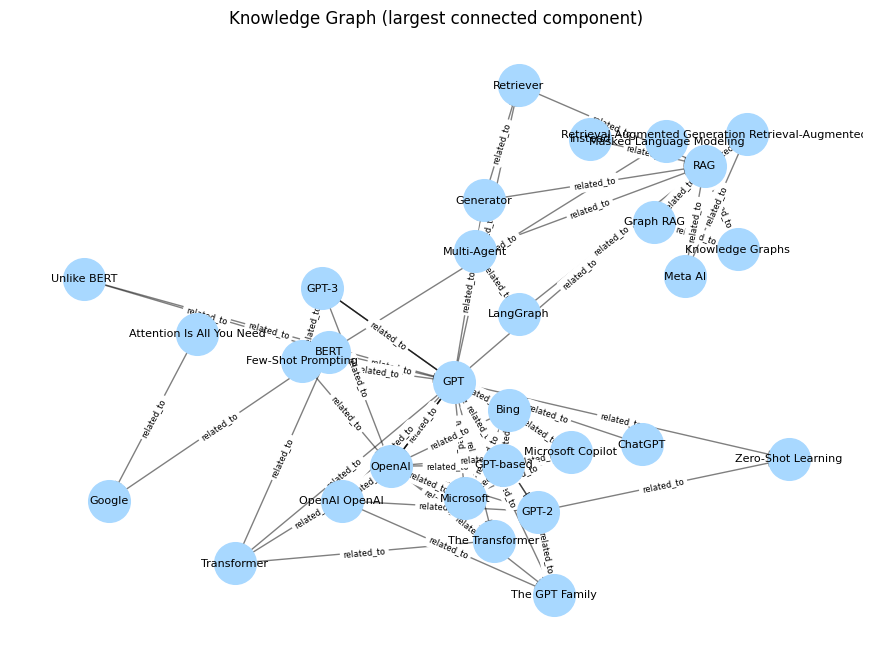

In [4]:
import matplotlib.pyplot as plt
import networkx as nx

# Show the largest connected component so the plot stays readable
undirected = graph.to_undirected()
largest_cc = max(nx.connected_components(undirected), key=len)
subgraph = graph.subgraph(largest_cc)

plt.figure(figsize=(11, 8))
pos = nx.spring_layout(subgraph, seed=42, k=0.6)
nx.draw_networkx_nodes(subgraph, pos, node_size=900, node_color="#a8d8ff")
nx.draw_networkx_labels(subgraph, pos, font_size=8)
nx.draw_networkx_edges(subgraph, pos, arrowsize=12, alpha=0.5)
edge_labels = {(u, v): d.get("relation", "") for u, v, d in subgraph.edges(data=True)}
nx.draw_networkx_edge_labels(subgraph, pos, edge_labels=edge_labels, font_size=6)
plt.title("Knowledge Graph (largest connected component)")
plt.axis("off")
plt.show()


## 4. Retrieval + Reasoning + Synthesis Agents

Wired together as a LangGraph state machine in `src/graph_orchestrator.py`.
The Reasoning Agent can loop back to Retrieval for another hop if the
context isn't sufficient yet (bounded by `KG_MAX_REASONING_HOPS`).

In [5]:
retriever = HybridRetriever(chunks)
query_graph = build_query_graph(retriever, graph, list(graph.nodes))


## 5. Ask questions

In [6]:
questions = [
    "What is Self-Attention and why does it matter for Transformers?",
    "How is BERT related to the Transformer architecture Google introduced?",
    "What company built ChatGPT, and how does RLHF fit into that story?",
    "How does Graph RAG differ from plain Retrieval-Augmented Generation?",
]

for q in questions:
    result = query_graph.invoke({"question": q, "hop": 0})
    print("Q:", q)
    print("A:", result["answer"])
    print(f"  -> {result['hop']} hop(s), {len(result['chunks'])} chunk(s), {len(result['graph_facts'])} graph fact(s)")
    print("-" * 100)


Q: What is Self-Attention and why does it matter for Transformers?
A: [01_transformers.txt::chunk0] The Transformer Architecture The Transformer architecture was introduced by a team of researchers at Google in 2017 in the paper "Attention Is All You Need". It replaced older sequence models such as Recurrent Neural Networks and Long Short-Term Memory networks by relying entirely on a mechanism called Self-Attention. Self-Attention allows a model to weigh the importance of every word in a sentence relative to every other word, which makes training highly parallelizable on GPUs and TPUs.
  -> 1 hop(s), 4 chunk(s), 44 graph fact(s)
----------------------------------------------------------------------------------------------------
Q: How is BERT related to the Transformer architecture Google introduced?
A: [01_transformers.txt::chunk0] The Transformer Architecture The Transformer architecture was introduced by a team of researchers at Google in 2017 in the paper "Attention Is All You Need

## 6. Try your own question

In [7]:
my_question = "How does Multi-Head Attention connect to the Retriever component of a RAG pipeline?"
result = query_graph.invoke({"question": my_question, "hop": 0})
print(result["answer"])


[01_transformers.txt::chunk0] The Transformer Architecture The Transformer architecture was introduced by a team of researchers at Google in 2017 in the paper "Attention Is All You Need". It replaced older sequence models such as Recurrent Neural Networks and Long Short-Term Memory networks by relying entirely on a mechanism called Self-Attention. Self-Attention allows a model to weigh the importance of every word in a sentence relative to every other word, which makes training highly parallelizable on GPUs and TPUs.


## Notes on design choices

- **Why a knowledge graph and not just vector search?** Vector similarity
  finds passages that *sound* like the question, but misses facts that are
  only connected through an intermediate entity (multi-hop reasoning).
  Traversing the graph a couple of hops out from matched entities recovers
  those connections directly.
- **Why LangGraph instead of a hand-rolled loop?** The Reasoning agent needs
  to conditionally send control back to Retrieval. LangGraph's
  `StateGraph` + conditional edges express that control flow declaratively
  and make the hop limit and state explicit and testable.
- **Why does everything degrade gracefully to a free/offline mode?** So the
  project runs identically in CI, in a grader's sandbox, or on a laptop
  with no budget for API calls, while still upgrading automatically the
  moment a free-tier key (Groq/Gemini) or a local Ollama model is available.
